# Ndjoka Tontine — Score de fiabilité prédictif (Data & IA)

**Objectif** : remplacer le score de fiabilité actuel, calculé par une formule fixe, par un **modèle de machine learning** qui prédit la probabilité qu'une cotisation soit **payée en retard ou impayée**.

**Le problème du score actuel** (`backend/app/modules/profiles/reliability.py`) :

```
score = 0.350 + 0.500 × taux_ponctualité − min(0.080 × impayés, 0.250) + 0.030 × min(cycles_terminés, 5)
```

1. Les poids (0.35, 0.50, 0.08…) ont été **choisis à la main**, rien ne prouve qu'ils sont bons.
2. Il **ignore le profil d'épargnant** (capacité, objectif, expérience…) alors que l'application le collecte déjà.
3. Un **nouvel arrivant** a toujours 0.500 : le score ne sait rien distinguer entre deux nouveaux membres.
4. Il ne tient pas compte du **contexte** de la cotisation (le membre a-t-il déjà reçu le pot ? le montant est-il lourd pour lui ?).

**Démarche** : 1) données → 2) analyse exploratoire → 3) modèle → 4) comparaison avec la formule actuelle → 5) export pour l'API.

> ⚠️ **Données simulées.** La plateforme n'a pas encore assez d'historique réel pour entraîner un modèle. On génère donc un jeu de données **qui respecte exactement le schéma de la base Ndjoka** (profils, tontines, cycles, cotisations). Le pipeline est prêt à être ré-entraîné sur les vraies données dès qu'elles seront suffisantes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.inspection import permutation_importance
import joblib

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

## 1. Génération des données (même structure que la base Ndjoka)

On simule :
- **900 utilisateurs** avec leur profil d'épargnant (les 7 variables de `SaverProfileInput`) ;
- **150 tontines** avec un montant de cotisation, une fréquence (`weekly` / `monthly`) et une taille ;
- des **cycles** avec un calendrier de tours (`CycleTurn`), et pour chaque tour une **cotisation** par membre (`Contribution`), avec sa date d'échéance.

Le comportement de paiement dépend de facteurs réalistes, inspirés du fonctionnement des tontines :
- **Taux d'effort** : cotisation mensuelle / capacité mensuelle déclarée. Plus il est élevé, plus le retard est probable.
- **Expérience** de la tontine.
- **Aléa moral** : une fois qu'il a reçu le pot, un membre est moins motivé à payer à l'heure.
- **Saisonnalité** : rentrée scolaire (septembre) et fêtes (décembre) pèsent sur les budgets.
- **Discipline personnelle** : une variable **cachée** (non observée par l'application), comme dans la réalité.

In [2]:
N_USERS, N_TONTINES = 900, 150

users = pd.DataFrame({
    "user_id": np.arange(N_USERS),
    "monthly_capacity": np.round(rng.lognormal(mean=np.log(90_000), sigma=0.55, size=N_USERS), -3),  # FCFA
    "preferred_rhythm": rng.choice(["weekly", "monthly"], N_USERS, p=[0.35, 0.65]),
    "savings_goal": rng.choice(["project", "emergency", "housing", "education", "business"], N_USERS,
                               p=[0.25, 0.15, 0.20, 0.20, 0.20]),
    "horizon_months": rng.integers(3, 37, N_USERS),
    "group_size_preference": rng.choice(["small", "medium", "large"], N_USERS, p=[0.35, 0.45, 0.20]),
    "experience_level": rng.choice(["beginner", "intermediate", "experienced"], N_USERS, p=[0.40, 0.35, 0.25]),
    "turn_preference": rng.choice(["early", "flexible", "late"], N_USERS, p=[0.40, 0.40, 0.20]),
})
# Variable cachée : discipline personnelle (l'application ne la connaît pas)
users["_discipline"] = rng.normal(0, 1, N_USERS)

tontines = pd.DataFrame({
    "tontine_id": np.arange(N_TONTINES),
    "frequency": rng.choice(["weekly", "monthly"], N_TONTINES, p=[0.35, 0.65]),
    "n_members": rng.integers(4, 13, N_TONTINES),
})
base_amount = np.round(rng.lognormal(np.log(40_000), 0.5, N_TONTINES), -3)
tontines["contribution_amount"] = np.where(tontines["frequency"] == "weekly",
                                           np.round(base_amount / 4.333, -2), base_amount)
tontines["monthly_equivalent"] = np.where(tontines["frequency"] == "weekly",
                                          tontines["contribution_amount"] * 4.333, tontines["contribution_amount"])
users.head()

,user_id,monthly_capacity,preferred_rhythm,savings_goal,horizon_months,group_size_preference,experience_level,turn_preference,_discipline
0,0,106000.0,monthly,housing,9,medium,intermediate,early,0.868472
1,1,51000.0,monthly,project,21,small,beginner,early,-1.818758
2,2,136000.0,monthly,project,4,small,intermediate,early,-1.501059
3,3,151000.0,weekly,project,14,small,experienced,early,-0.736008
4,4,31000.0,monthly,project,21,medium,intermediate,flexible,-0.129820


In [3]:
EXP = {"beginner": 0.0, "intermediate": -0.35, "experienced": -0.7}
GOAL = {"project": 0.0, "emergency": 0.25, "housing": -0.1, "education": 0.05, "business": 0.1}

def sigmoid(x): return 1 / (1 + np.exp(-x))

rows = []
start_dates = pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 600, N_TONTINES), unit="D")
for t in tontines.itertuples():
    members = rng.choice(N_USERS, size=t.n_members, replace=False)
    order = rng.permutation(members)                      # calendrier des bénéficiaires (CycleTurn)
    step = pd.Timedelta(days=7) if t.frequency == "weekly" else pd.DateOffset(months=1)
    for position, beneficiary in enumerate(order, start=1):
        due_at = start_dates[t.tontine_id] + step * (position - 1)
        for uid in members:
            if uid == beneficiary:
                continue                                  # beneficiary_contributes = False
            u = users.loc[uid]
            effort = t.monthly_equivalent / u.monthly_capacity
            already_received = int(np.where(order == uid)[0][0] + 1 < position)
            month = due_at.month
            logit = (-2.4
                     + 2.2 * max(effort - 0.5, 0)          # effort au-delà de 50 % de la capacité
                     + 0.6 * effort
                     + EXP[u.experience_level]
                     + GOAL[u.savings_goal]
                     + 0.9 * already_received              # aléa moral
                     + 0.45 * (month in (9, 12))           # rentrée scolaire / fêtes
                     + 0.25 * (t.frequency == "weekly")
                     - 0.9 * u._discipline)                # facteur caché
            p_problem = sigmoid(logit)
            r = rng.random()
            if r < p_problem * 0.78:
                outcome = "late"
            elif r < p_problem:
                outcome = "unpaid"
            else:
                outcome = "on_time"
            rows.append(dict(tontine_id=t.tontine_id, user_id=uid, position=position,
                             n_members=t.n_members, frequency=t.frequency,
                             contribution_amount=t.contribution_amount,
                             monthly_equivalent=t.monthly_equivalent,
                             due_at=due_at, already_received=already_received, outcome=outcome))

contrib = pd.DataFrame(rows).sort_values(["user_id", "due_at"]).reset_index(drop=True)
contrib["is_problem"] = (contrib["outcome"] != "on_time").astype(int)   # cible : retard OU impayé
print(f"{len(contrib):,} cotisations simulées pour {contrib.user_id.nunique()} membres")
contrib["outcome"].value_counts(normalize=True).round(3)

9,950 cotisations simulées pour 676 membres


outcome
on_time    0.745
late       0.200
unpaid     0.055
Name: proportion, dtype: float64

## 2. Analyse exploratoire

Avant de modéliser, on regarde ce que disent les données : **qui** paie en retard, **quand**, et **pourquoi**.

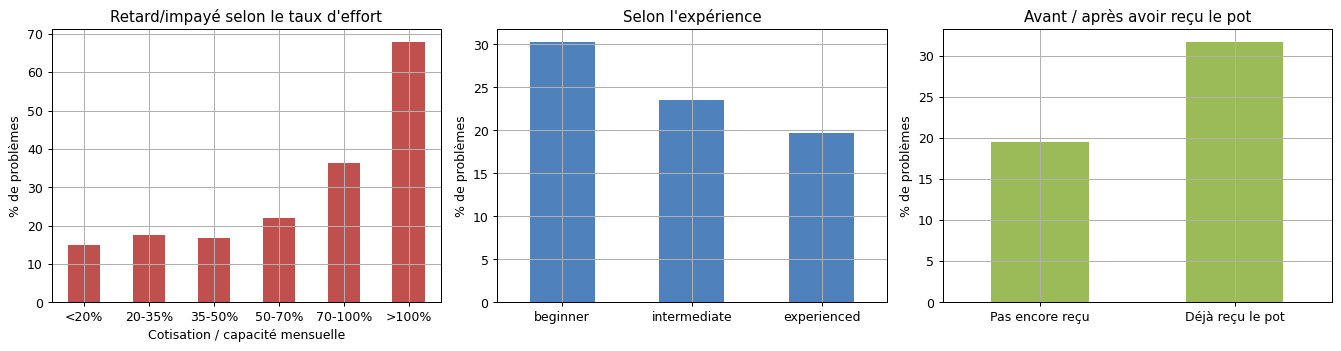

In [4]:
df = contrib.merge(users.drop(columns="_discipline"), on="user_id")
df["effort_ratio"] = df["monthly_equivalent"] / df["monthly_capacity"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = pd.cut(df["effort_ratio"], [0, 0.2, 0.35, 0.5, 0.7, 1, 10],
              labels=["<20%", "20-35%", "35-50%", "50-70%", "70-100%", ">100%"])
df.groupby(bins, observed=True)["is_problem"].mean().mul(100).plot.bar(ax=axes[0], color="#c0504d")
axes[0].set(title="Retard/impayé selon le taux d'effort", xlabel="Cotisation / capacité mensuelle", ylabel="% de problèmes")

df.groupby("experience_level")["is_problem"].mean().mul(100).reindex(["beginner", "intermediate", "experienced"]) \
  .plot.bar(ax=axes[1], color="#4f81bd")
axes[1].set(title="Selon l'expérience", xlabel="", ylabel="% de problèmes")

df.groupby("already_received")["is_problem"].mean().mul(100).rename({0: "Pas encore reçu", 1: "Déjà reçu le pot"}) \
  .plot.bar(ax=axes[2], color="#9bbb59")
axes[2].set(title="Avant / après avoir reçu le pot", xlabel="", ylabel="% de problèmes")
for ax in axes: ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

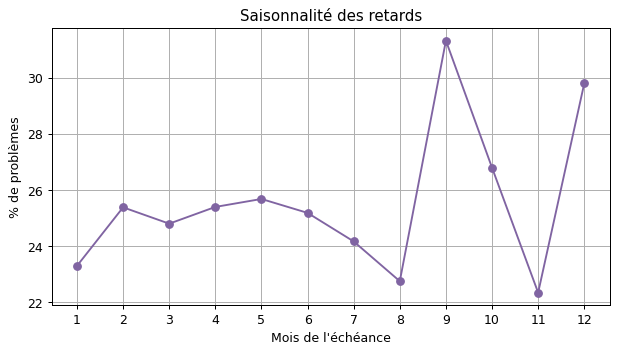

In [5]:
monthly = df.groupby(df["due_at"].dt.month)["is_problem"].mean().mul(100)
fig, ax = plt.subplots(figsize=(8, 4))
monthly.plot(ax=ax, marker="o", color="#8064a2")
ax.set(title="Saisonnalité des retards", xlabel="Mois de l'échéance", ylabel="% de problèmes", xticks=range(1, 13))
plt.show()

**Ce qu'on retient** :
- Le **taux d'effort** est le facteur le plus fort : au-delà de 50 % de sa capacité, le risque explose. L'application collecte déjà la capacité mais la formule actuelle ne l'utilise pas.
- Les **débutants** sont plus souvent en retard.
- **Après avoir reçu le pot**, les membres paient moins bien : c'est le risque principal d'une tontine.
- **Septembre et décembre** sont des mois à risque.

## 3. Construction des variables (feature engineering)

Pour chaque cotisation, on ne doit utiliser **que ce qu'on savait avant l'échéance** (sinon le modèle "triche"). On calcule donc l'historique du membre **jusqu'à la cotisation précédente**, exactement comme le fait `reliability.py`.

In [6]:
df = df.sort_values(["user_id", "due_at"]).reset_index(drop=True)
g = df.groupby("user_id")
df["hist_n"] = g.cumcount()                                             # cotisations passées
df["hist_late"] = g["outcome"].transform(lambda s: (s == "late").cumsum().shift(fill_value=0))
df["hist_unpaid"] = g["outcome"].transform(lambda s: (s == "unpaid").cumsum().shift(fill_value=0))
df["hist_on_time_rate"] = np.where(df["hist_n"] > 0,
                                   (df["hist_n"] - df["hist_late"] - df["hist_unpaid"]) / df["hist_n"].clip(lower=1),
                                   np.nan)
df["due_month"] = df["due_at"].dt.month
df["risky_month"] = df["due_month"].isin([9, 12]).astype(int)

# Score actuel de Ndjoka (reproduction de reliability.py), calculé sur l'historique disponible
def current_formula(row):
    if row.hist_n == 0:
        return 0.5
    s = 0.35 + 0.5 * row.hist_on_time_rate - min(0.08 * row.hist_unpaid, 0.25)  # cycles terminés ~ 0 ici
    return float(np.clip(s, 0, 1))
df["current_score"] = df.apply(current_formula, axis=1)

NUM = ["effort_ratio", "monthly_capacity", "horizon_months", "hist_n", "hist_late", "hist_unpaid",
       "hist_on_time_rate", "already_received", "position", "n_members", "risky_month"]
CAT = ["experience_level", "savings_goal", "frequency", "preferred_rhythm", "turn_preference"]
df[NUM + CAT + ["current_score", "is_problem"]].head()

,effort_ratio,monthly_capacity,horizon_months,hist_n,hist_late,hist_unpaid,hist_on_time_rate,already_received,position,n_members,risky_month,experience_level,savings_goal,frequency,preferred_rhythm,turn_preference,current_score,is_problem
0,0.481132,106000.0,9,0,0,0,NaN,0,1,10,0,intermediate,housing,monthly,monthly,early,0.50,0
1,0.481132,106000.0,9,1,0,0,1.0,0,2,10,1,intermediate,housing,monthly,monthly,early,0.85,0
2,0.481132,106000.0,9,2,0,0,1.0,0,3,10,0,intermediate,housing,monthly,monthly,early,0.85,0
3,0.481132,106000.0,9,3,0,0,1.0,0,4,10,0,intermediate,housing,monthly,monthly,early,0.85,0
4,0.481132,106000.0,9,4,0,0,1.0,1,6,10,0,intermediate,housing,monthly,monthly,early,0.85,0


## 4. Entraînement des modèles

On sépare **par membre** : 80 % des membres pour l'entraînement, 20 % pour le test. Le modèle est donc évalué sur des personnes **qu'il n'a jamais vues**.

On compare :
1. **La formule actuelle** de Ndjoka (référence) ;
2. Une **régression logistique** (simple et explicable) ;
3. Un **Gradient Boosting** (plus puissant, capte les effets non linéaires comme le seuil de 50 % d'effort).

Métrique : **AUC** (0.5 = hasard, 1 = parfait). Elle mesure la capacité à classer les membres risqués avant les membres fiables.

In [7]:
X, y, groups = df[NUM + CAT], df["is_problem"], df["user_id"]
train_idx, test_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0).split(X, y, groups))
X_train, X_test, y_train, y_test = X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

X_train_f = X_train.fillna({"hist_on_time_rate": -1}); X_test_f = X_test.fillna({"hist_on_time_rate": -1})

logreg = Pipeline([
    ("prep", ColumnTransformer([("num", StandardScaler(), NUM),
                                ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])),
    ("model", LogisticRegression(max_iter=2000)),
]).fit(X_train_f, y_train)

gb = Pipeline([
    ("prep", ColumnTransformer([("num", "passthrough", NUM),
                                ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)])),
    ("model", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=4, random_state=0)),
]).fit(X_train_f, y_train)

scores = {
    "Formule actuelle Ndjoka": 1 - df["current_score"].iloc[test_idx],   # risque = 1 - fiabilité
    "Régression logistique": logreg.predict_proba(X_test_f)[:, 1],
    "Gradient Boosting": gb.predict_proba(X_test_f)[:, 1],
}
results = pd.Series({k: roc_auc_score(y_test, v) for k, v in scores.items()}, name="AUC").round(3)
results

Formule actuelle Ndjoka    0.686
Régression logistique      0.769
Gradient Boosting          0.762
Name: AUC, dtype: float64

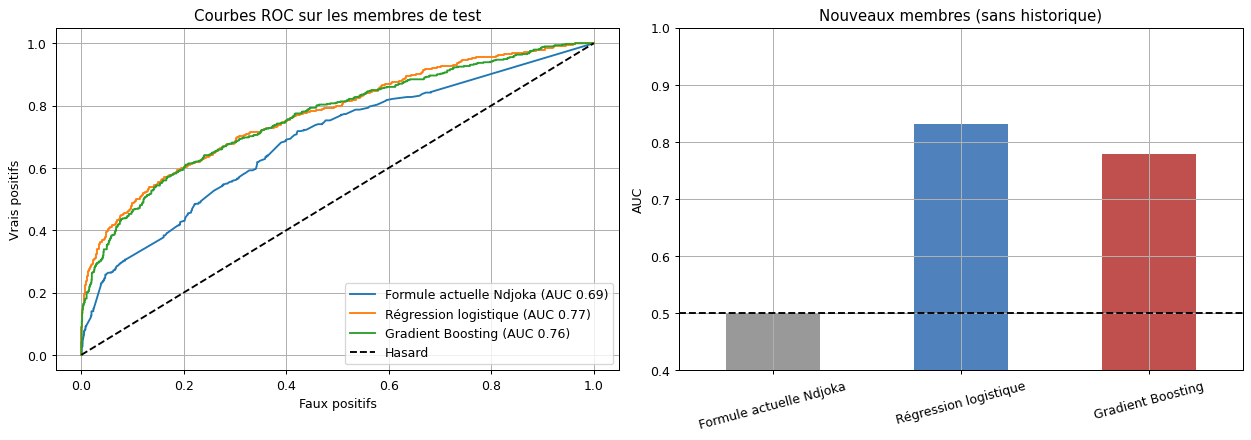

Formule actuelle Ndjoka    0.500
Régression logistique      0.831
Gradient Boosting          0.779
dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_test, s)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, s):.2f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Hasard")
axes[0].set(title="Courbes ROC sur les membres de test", xlabel="Faux positifs", ylabel="Vrais positifs"); axes[0].legend()

# Focus : nouveaux membres (aucun historique) — la formule actuelle donne 0.5 à tout le monde
new = (X_test["hist_n"] == 0).values
cold = pd.Series({k: roc_auc_score(y_test[new], np.asarray(v)[new]) if len(set(np.asarray(v)[new])) > 1 else 0.5
                  for k, v in scores.items()})
cold.plot.bar(ax=axes[1], color=["#999999", "#4f81bd", "#c0504d"])
axes[1].axhline(0.5, color="k", ls="--"); axes[1].set(title="Nouveaux membres (sans historique)", ylabel="AUC", ylim=(0.4, 1))
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()
cold.round(3)

**Lecture** :
- Les deux modèles de machine learning classent nettement mieux les membres risqués que la formule actuelle. La régression logistique fait aussi bien que le Gradient Boosting : on peut privilégier le modèle le plus simple et le plus explicable.
- Sur les **nouveaux membres**, la formule actuelle est au niveau du hasard (tout le monde à 0.5), alors que le modèle s'appuie sur le **profil d'épargnant** et le **contexte** de la cotisation. C'est le gain le plus concret pour l'application : un organisateur peut évaluer un nouveau membre dès son inscription.

## 5. Explicabilité : qu'est-ce qui compte pour le modèle ?

Dans la finance, un score doit être **explicable** (on ne refuse pas quelqu'un sans raison). On mesure l'importance de chaque variable par **permutation** : on mélange une variable et on regarde combien la performance baisse.

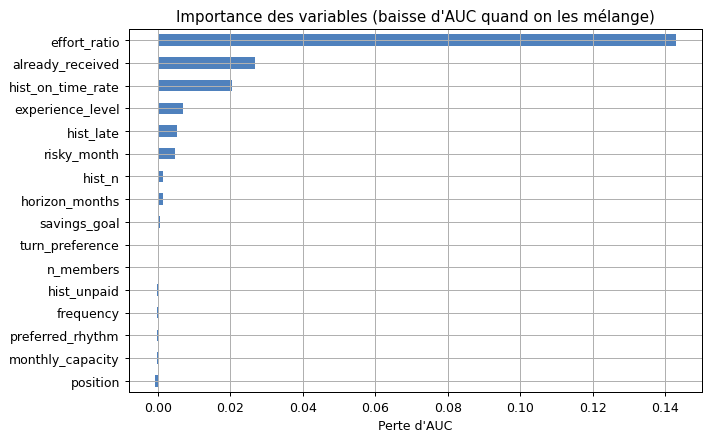

In [9]:
imp = permutation_importance(gb, X_test_f, y_test, scoring="roc_auc", n_repeats=5, random_state=0)
importance = pd.Series(imp.importances_mean, index=NUM + CAT).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
importance.plot.barh(ax=ax, color="#4f81bd")
ax.set(title="Importance des variables (baisse d'AUC quand on les mélange)", xlabel="Perte d'AUC")
plt.tight_layout(); plt.show()

## 6. Du risque au score Ndjoka

Pour rester compatible avec l'application (score entre 0 et 1, paliers `excellent` / `bon` / `moyen` / `fragile`), on transforme la probabilité de problème en score : **score = 1 − probabilité de retard**. On vérifie que les paliers ont un sens : le taux réel de problèmes doit baisser d'un palier à l'autre.

In [10]:
def band(score):
    return "excellent" if score >= 0.80 else "bon" if score >= 0.65 else "moyen" if score >= 0.45 else "fragile"

test = X_test.copy()
test["ml_score"] = 1 - scores["Gradient Boosting"]
test["band"] = test["ml_score"].apply(band)
test["is_problem"] = y_test.values
calib = test.groupby("band")["is_problem"].agg(["count", "mean"]).reindex(["excellent", "bon", "moyen", "fragile"])
calib.columns = ["nb cotisations", "taux réel de retard/impayé"]
calib.round(3)

,nb cotisations,taux réel de retard/impayé
band,,
excellent,971,0.131
bon,414,0.237
moyen,193,0.378
fragile,285,0.684


## 7. Export du modèle pour l'API FastAPI

On sauvegarde le modèle entraîné. Le backend le chargera au démarrage pour exposer une nouvelle route (par exemple `GET /api/v1/me/reliability/prediction`).

In [11]:
FEATURES = {"numeric": NUM, "categorical": CAT}
joblib.dump({"model": gb, "features": FEATURES, "version": "0.1-simulated"}, "reliability_model.joblib")
df.drop(columns=["_discipline"], errors="ignore").to_csv("ndjoka_contributions_simulees.csv", index=False)
print("Modèle et données exportés.")

# Exemple : prédiction pour un nouveau membre
exemple = pd.DataFrame([{
    "effort_ratio": 0.75, "monthly_capacity": 80_000, "horizon_months": 12, "hist_n": 0, "hist_late": 0,
    "hist_unpaid": 0, "hist_on_time_rate": -1, "already_received": 0, "position": 3, "n_members": 8,
    "risky_month": 1, "experience_level": "beginner", "savings_goal": "emergency", "frequency": "monthly",
    "preferred_rhythm": "monthly", "turn_preference": "early"}])
p = gb.predict_proba(exemple)[0, 1]
print(f"Probabilité de retard : {p:.0%}  →  score Ndjoka {1-p:.2f} ({band(1-p)})")

Modèle et données exportés.
Probabilité de retard : 34%  →  score Ndjoka 0.66 (bon)


## 8. Limites et suite

- **Données simulées** : les relations découvertes par le modèle sont celles qu'on a mises dans la simulation. Le vrai intérêt est le **pipeline** : dès que la plateforme aura quelques milliers de cotisations réelles, il suffit de remplacer l'étape 1 par une requête SQL sur les tables `contributions`, `saver_profiles`, `cycles` et de ré-entraîner.
- **Équité** : un score qui conditionne l'accès à une tontine (`min_reliability_score`) doit être surveillé pour ne pas pénaliser injustement un groupe (par ex. les débutants). Il faut garder des explications lisibles, comme le champ `explanation` actuel.
- **Évolutions** : ré-entraînement mensuel automatique, ordre des bénéficiaires optimisé selon le risque (les profils fragiles reçoivent le pot plus tard), et apprentissage du score d'affinité du module discovery à partir des adhésions réelles.